In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None) # show full dataframe

In [3]:
# import data
X = pd.read_csv("../data/training_set_values.csv")
y = pd.read_csv("../data/training_set_labels.csv")

# split data into train and test data
data = pd.merge(X, y, on="id")

In [4]:
repair = data.loc[data["status_group"] == "functional needs repair"]
functional = data.loc[data["status_group"] == "functional"]
non_functional = data.loc[data["status_group"] == "non functional"]


df = data[data['status_group'].isin(["functional needs repair", "functional"])]
df1 = data[data['status_group'].isin(["functional needs repair", "non functional"])]
df0 = data[data['status_group'].isin(["functional", "non functional"])]


In [5]:
col = "installer"

df2 = data.copy()
N = 10
top_n = df2[col].value_counts().nlargest(N).index.tolist()

# additionally force-keep these rare categories
# extra_keep = ["Mkongoro One", "Mkongoro Two"]
extra_keep = []


keep_values = list(set(top_n + extra_keep))

df2[col] = df2[col].where(
    df2[col].isin(keep_values),
    "Other"
)
print(df2[col].unique())



df2_repair = df2.loc[df2["status_group"] == "functional needs repair"]
df2_functional = df2.loc[df2["status_group"] == "functional"]
df2_non_functional = df2.loc[df2["status_group"] == "non functional"]

df3 = df2[df2['status_group'].isin(["functional needs repair", "functional"])]
df4 = df2[df2['status_group'].isin(["functional needs repair", "non functional"])]


['Other' 'DWE' 'DANIDA' 'Central government' 'Commu' 'Government' 'KKKT'
 'RWE' 'Hesawa' '0' 'TCRS']


In [5]:
repair.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,4317.000000,4317.000000,4317.000000,4317.000000,4.317000e+03,4317.000000,4317.000000,4317.000000,4317.000000,4317.000000
mean,37151.263609,267.071577,627.607135,31.242086,-5.162580e+00,0.307621,15.443595,4.759092,175.102154,1168.406764
std,21340.576248,1925.026420,648.397850,10.169667,3.099036e+00,4.736658,16.346936,8.062250,433.033756,983.063724
min,20.000000,0.000000,-51.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18715.000000,0.000000,0.000000,30.799300,-7.860679e+00,0.000000,6.000000,1.000000,0.000000,0.000000
50%,37180.000000,0.000000,385.000000,33.827215,-4.656811e+00,0.000000,15.000000,3.000000,25.000000,1978.000000
75%,55706.000000,50.000000,1243.000000,36.668018,-3.158054e+00,0.000000,17.000000,4.000000,245.000000,2000.000000
max,74233.000000,100000.000000,2770.000000,40.283599,-2.000000e-08,160.000000,99.000000,80.000000,15300.000000,2013.000000


In [6]:
functional.describe(include=object)

,date_recorded,funder,installer,wpt_name,basin,subvillage,region,lga,ward,public_meeting,recorded_by,scheme_management,scheme_name,permit,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
count,32259,30277,30259,32259,32259,32054,32259,32259,32259,30581,32259,30385,17359,30586,32259,32259,32259,32259,32259,32259,32259,32259,32259,32259,32259,32259,32259,32259,32259,32259,32259
unique,333,1420,1518,21368,9,12771,21,124,1983,2,1,11,1919,2,17,13,7,12,5,7,7,8,6,5,5,10,7,3,7,6,1
top,17/03/2011,Government Of Tanzania,DWE,none,Pangani,Madukani,Iringa,Njombe,Igosi,True,GeoData Consultants Ltd,VWC,K,True,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
freq,381,3720,9433,2630,5372,248,4141,2007,289,28408,32259,18960,376,21541,16048,16048,16048,20425,28252,11379,11379,28760,28760,21648,21648,10592,10592,24835,17726,19961,32259


<Figure size 1000x600 with 0 Axes>

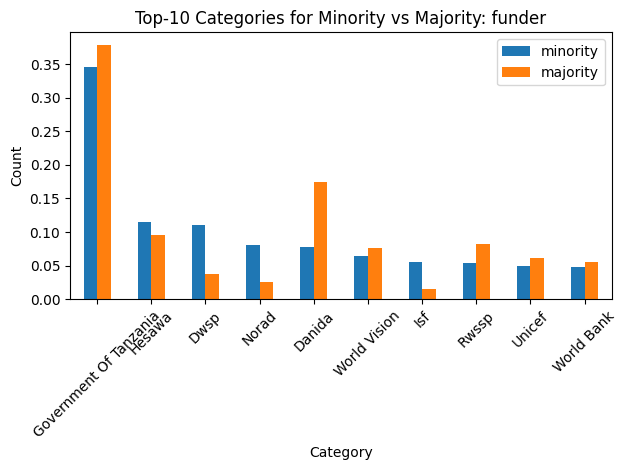

In [15]:
#funder, wpt_name, basin, scheme_name

feature = "funder"

# Count categories in each class
minority_counts = repair[feature].value_counts()
majority_counts = functional[feature].value_counts()

# Combine counts into one DataFrame
combined = pd.DataFrame({
    "minority": minority_counts,
    "majority": majority_counts
}).fillna(0)

# Compute difference (optional – useful for ranking)
combined["difference"] = combined["minority"] - combined["majority"]

# Pick Top-N categories by minority frequency or difference
N = 10
top_n = combined.sort_values("minority", ascending=False).head(N)
top_n_norm = top_n.div(top_n.sum(axis=0), axis=1)

# Plot bar chart
plt.figure(figsize=(10, 6))
top_n_norm[["minority", "majority"]].plot(kind="bar")
plt.title(f"Top-{N} Categories for Minority vs Majority: {feature}")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
df0.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,55083.000000,55083.000000,55083.000000,55083.000000,5.508300e+04,55083.000000,55083.000000,55083.000000,55083.000000,55083.000000
mean,37112.300020,321.614379,671.486230,34.299640,-5.748624e+00,0.487192,15.285515,5.697983,180.286785,1311.016920
std,21462.114645,3065.794824,696.404821,6.142341,2.929462e+00,12.637230,17.681036,9.742878,474.365391,948.342454
min,0.000000,0.000000,-90.000000,0.000000,-1.158630e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18502.000000,0.000000,0.000000,33.176482,-8.566286e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37051.000000,0.000000,368.000000,34.963928,-5.100971e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55651.500000,20.000000,1325.000000,37.206957,-3.332487e+00,0.000000,17.000000,5.000000,210.000000,2004.000000
max,74247.000000,350000.000000,2628.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


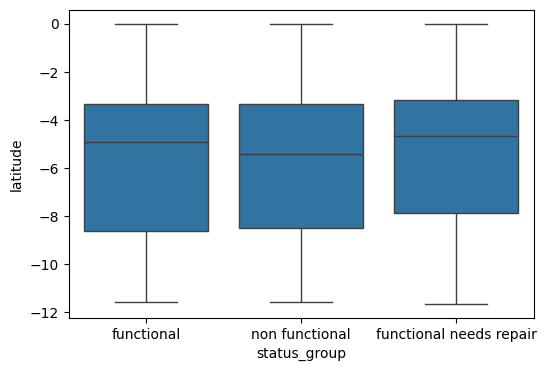

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x='status_group', y='latitude')
plt.show()

In [32]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    """
    Compute Cramér's V statistic for categorical association.
    A higher value means Feature_X differs more strongly between minority and majority classes.
    """
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    
    # Corrected Cramér's V (bias-corrected)
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2_corr / min((r_corr-1), (k_corr-1)))


### test 
categorical_features = ["region", "basin", "payment_type", "quality_group", "installer"]

results = []

for col in categorical_features:
    cm = pd.crosstab(df1[col], df1["status_group"])
    cv = cramers_v(cm)
    results.append((col, cv))

# Sort by strongest association
results = sorted(results, key=lambda x: x[1], reverse=True)

for feature, value in results:
    print(f"{feature}: {value:.4f}")

installer: 0.3076
region: 0.2473
payment_type: 0.1868
quality_group: 0.1188
basin: 0.1048


### Analysis report

- basin for repair vs. functional
- 